In [1]:
import pandas as pd
import csv
import numpy as np
import matplotlib.pyplot as plt

## Read in ID/Name/Category Map

In [2]:
# Read in the category_mapping data
type_map = pd.read_csv('../Data/id_name_category.csv', delimiter=",")

## Set PA, FL, CA file paths

In [7]:
PA = '../Data/pennsylvania.csv'
FL = '../Data/florida.csv'
CA = '../Data/california.csv'

## Begin script to aggregate mean for City * Category (Type)

In [4]:
def load_data(path):
    STATE = pd.read_csv(path, delimiter = ',')
    STATE.rename(columns={'date': 'time'}, inplace = True)
    STATE['time'] = pd.to_datetime(STATE['time'])
    STATE['date'] = STATE['time'].dt.date
    return STATE

In [5]:
def process(path):
    df = load_data(path)
    df_grouped = df.drop(columns=['state', 'review_id', 'review', 'aspect_sentiments', 'stars', 'total_review_count', 'rating'])
    df_grouped = df_grouped.groupby(
        ['business_id', 
         'business_name', 
         'city', 
         'longitude', 
         'latitude', 
         'time', 
         'date']).mean()
    df_HalfYear_MultiIndexed = df_grouped.groupby(
        [pd.Grouper(level = 'business_id'), 
        pd.Grouper(level = 'business_name'), 
        pd.Grouper(level = 'city'), 
        pd.Grouper(level = 'longitude'), 
        pd.Grouper(level = 'latitude'), 
        pd.Grouper(level = 'date'),
        pd.Grouper(level = 'time', freq = '6M')]).mean()
    df_HalfYear_Flat = df_HalfYear_MultiIndexed.reset_index().rename(columns = {'time': 'time_period'})
    df_category = df_HalfYear_Flat.merge(type_map, on = 'business_id')
    df_category['category_avg_by_city'] = df_category.groupby(['category', 'city', 'time_period'])['doc_sentiment'].transform('mean')
    df_aggregated = df_category.groupby(
    ['business_id', 'business_name', 'city', 'longitude', 'latitude', 'time_period']
    ).agg(
        {'doc_sentiment': 'mean', 'category_avg_by_city': 'mean', 'category': lambda x: ', '.join(x)}
        ).reset_index()
    print('# Unique Businesses:',len(df_aggregated['business_id'].unique()))
    return df_aggregated

In [9]:
PA_data = process(PA)
display(PA_data.head())

# Unique Businesses: 34013


,business_id,business_name,city,longitude,latitude,time_period,doc_sentiment,category_avg_by_city,category
0,--30_8IhuyMHbSOcNWd6DQ,Action Karate,Jamison,-75.088399,40.255362,2012-08-31,0.7463,0.4474,"Trainers, Active Life, Fitness & Instruction..."
1,--30_8IhuyMHbSOcNWd6DQ,Action Karate,Jamison,-75.088399,40.255362,2013-02-28,0.9381,0.9381,"Trainers, Active Life, Fitness & Instruction..."
2,--30_8IhuyMHbSOcNWd6DQ,Action Karate,Jamison,-75.088399,40.255362,2013-08-31,-0.8837,-0.8837,"Trainers, Active Life, Fitness & Instruction..."
3,--30_8IhuyMHbSOcNWd6DQ,Action Karate,Jamison,-75.088399,40.255362,2016-02-29,0.4013,0.4013,"Trainers, Active Life, Fitness & Instruction..."
4,--30_8IhuyMHbSOcNWd6DQ,Action Karate,Jamison,-75.088399,40.255362,2017-02-28,0.9321,0.8115,"Trainers, Active Life, Fitness & Instruction..."


In [10]:
FL_data = process(FL)
display(FL_data.head())

# Unique Businesses: 26309


,business_id,business_name,city,longitude,latitude,time_period,doc_sentiment,category_avg_by_city,category
0,---kPU91CF4Lq2-WlRu9Lw,Frankie's Raw Bar,New Port Richey,-82.733344,28.217288,2020-03-31,0.950925,0.642386,"Seafood, Restaurants, Latin American, Food,..."
1,---kPU91CF4Lq2-WlRu9Lw,Frankie's Raw Bar,New Port Richey,-82.733344,28.217288,2020-09-30,0.749020,0.666788,"Seafood, Restaurants, Latin American, Food,..."
2,---kPU91CF4Lq2-WlRu9Lw,Frankie's Raw Bar,New Port Richey,-82.733344,28.217288,2021-03-31,0.876025,0.684461,"Seafood, Restaurants, Latin American, Food,..."
3,---kPU91CF4Lq2-WlRu9Lw,Frankie's Raw Bar,New Port Richey,-82.733344,28.217288,2021-09-30,0.773500,0.667377,"Seafood, Restaurants, Latin American, Food,..."
4,---kPU91CF4Lq2-WlRu9Lw,Frankie's Raw Bar,New Port Richey,-82.733344,28.217288,2022-03-31,0.869822,0.731814,"Seafood, Restaurants, Latin American, Food,..."


In [11]:
CA_data = process(CA)
display(CA_data.head())

# Unique Businesses: 5202


,business_id,business_name,city,longitude,latitude,time_period,doc_sentiment,category_avg_by_city,category
0,--O3ip9NpXTKD4oBS1pY2A,Alameda Park,Santa Barbara,-119.705397,34.428303,2007-09-30,0.8729,0.898600,"Active Life, Parks"
1,--O3ip9NpXTKD4oBS1pY2A,Alameda Park,Santa Barbara,-119.705397,34.428303,2008-03-31,0.9851,0.948837,"Active Life, Parks, Active Life, Parks"
2,--O3ip9NpXTKD4oBS1pY2A,Alameda Park,Santa Barbara,-119.705397,34.428303,2008-09-30,0.8815,0.825508,"Active Life, Parks"
3,--O3ip9NpXTKD4oBS1pY2A,Alameda Park,Santa Barbara,-119.705397,34.428303,2009-09-30,0.9721,0.833454,"Active Life, Parks"
4,--O3ip9NpXTKD4oBS1pY2A,Alameda Park,Santa Barbara,-119.705397,34.428303,2010-09-30,0.6454,0.846745,"Active Life, Parks, Active Life, Parks"


## Write new PA/FL/CA data to csv

In [13]:
PA_data.to_csv('../Data/agg_mean_citytype_PA.csv', index = False)
FL_data.to_csv('../Data/agg_mean_citytype_FL.csv', index = False)
CA_data.to_csv('../Data/agg_mean_citytype_CA.csv', index = False)

## Sample plots for each state

In [14]:
def plot(state_data):
    random_business_id = state_data['business_id'].sample(n=1).unique()[0]
    print(random_business_id)
    sample = state_data[state_data['business_id'] == random_business_id]
    
    plt.figure(figsize = (6, 3))
    plt.plot(sample['time_period'],sample['doc_sentiment'],marker='o',label='Business Score')
    plt.plot(sample['time_period'],sample['category_avg_by_city'],marker='x',label='Category Average')
    plt.xticks(fontsize=6)
    plt.title('Business Sentiment Score versus Average Category Score over Time')
    plt.legend()
    plt.show()

Al8y5FTs9tW5VsxTVy9ZMg


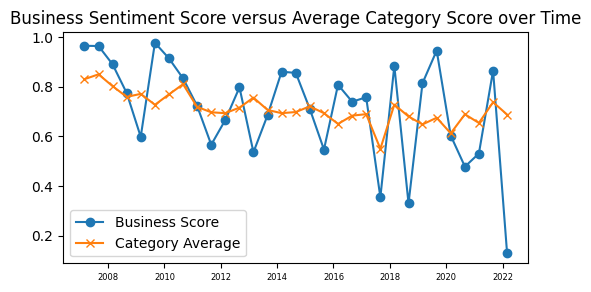

In [15]:
plot(PA_data)

nRGxU90L9oTr2YUSPNakKA


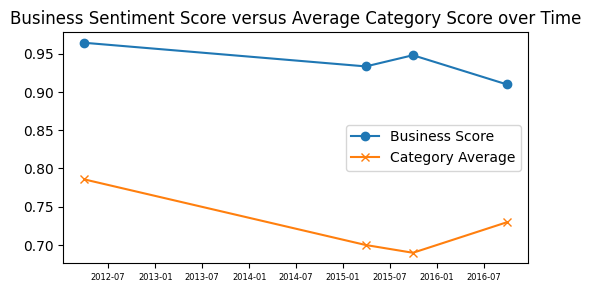

In [16]:
plot(FL_data)

0it-2gWk_gyuZyEMQzBBuQ


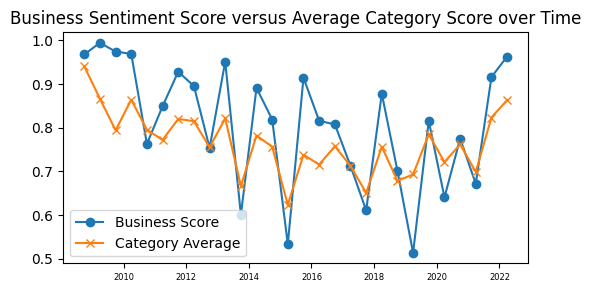

In [17]:
plot(CA_data)